In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/gourisharma32/playstore-csv/googleplaystore.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [3]:
df.isnull().sum()

# Drop rows where Rating is missing
df = df.dropna(subset=['Rating'])

In [4]:
df.drop_duplicates(inplace=True)

In [6]:
df[df['Installs'] == 'Free']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [7]:
df = df[df['Installs'] != 'Free']

In [8]:
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].astype(int)

In [10]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

In [11]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)

In [12]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [13]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             8892 non-null   object        
 1   Category        8892 non-null   object        
 2   Rating          8892 non-null   float64       
 3   Reviews         8892 non-null   int64         
 4   Size            7424 non-null   float64       
 5   Installs        8892 non-null   int64         
 6   Type            8892 non-null   object        
 7   Price           8892 non-null   float64       
 8   Content Rating  8892 non-null   object        
 9   Genres          8892 non-null   object        
 10  Last Updated    8892 non-null   datetime64[ns]
 11  Current Ver     8888 non-null   object        
 12  Android Ver     8890 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 972.6+ KB


In [15]:
df.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size              1468
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          4
Android Ver          2
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df['Installs'] <= 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [18]:
df[(df['Rating'] < 0) | (df['Rating'] > 5)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [19]:
df[df['Price'] < 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [20]:
df[df['Size'] < 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [21]:
df['Type'].unique()
df['Content Rating'].unique()
df['Category'].nunique()

33

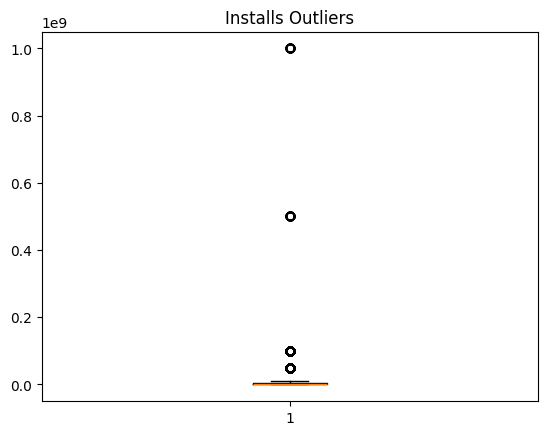

In [22]:
plt.boxplot(df['Installs'])
plt.title("Installs Outliers")
plt.show()

In [23]:
df.to_csv("cleanest_google_playstore.csv", index=False)

In [24]:
print(df.shape)
print(df.head())

(8892, 13)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

   Reviews  Size  Installs  Type  Price Content Rating  \
0      159  19.0     10000  Free    0.0       Everyone   
1      967  14.0    500000  Free    0.0       Everyone   
2    87510   8.7   5000000  Free    0.0       Everyone   
3   215644  25.0  50000000  Free    0.0           Teen   
4      967   2.8    100000  Free    0.0       Everyone   

                      Genres Last Updated         Current Ver   Android Ver  
0               Art & Design   2018-01-07               1.0.0  4.0.3 and up  
1  

In [25]:
df['Rating'].mean()

np.float64(4.187876743139901)

In [26]:
df['Category'].nunique()

33

In [27]:
df['Type'].value_counts()

Type
Free    8279
Paid     613
Name: count, dtype: int64

In [28]:
df['Content Rating'].mode()

0    Everyone
Name: Content Rating, dtype: object

In [29]:
df.sort_values(by='Installs', ascending=False)[['App','Installs']].head()

,App,Installs
3896,Subway Surfers,1000000000
4153,Hangouts,1000000000
4150,Google,1000000000
3904,WhatsApp Messenger,1000000000
3816,Google News,1000000000


In [30]:
df[df['Rating'] >= 4].shape[0]

6947

In [31]:
df.groupby('Type')['Reviews'].mean()

Type
Free    506682.471675
Paid     14850.365416
Name: Reviews, dtype: float64

In [32]:
df.groupby('Category')['Size'].mean().sort_values(ascending=False)

Category
GAME                   45.102102
FAMILY                 29.741249
SPORTS                 26.445611
TRAVEL_AND_LOCAL       25.128691
FOOD_AND_DRINK         24.057317
HEALTH_AND_FITNESS     23.056692
ENTERTAINMENT          22.638806
PARENTING              21.579545
AUTO_AND_VEHICLES      21.541211
EDUCATION              20.035333
MEDICAL                19.246883
FINANCE                18.610992
SOCIAL                 18.268768
HOUSE_AND_HOME         17.678000
DATING                 17.597872
MAPS_AND_NAVIGATION    17.448635
PHOTOGRAPHY            17.032073
SHOPPING               16.913520
VIDEO_PLAYERS          16.164325
BEAUTY                 15.513514
LIFESTYLE              15.513314
EVENTS                 14.432268
BOOKS_AND_REFERENCE    14.227896
BUSINESS               14.010306
WEATHER                13.405262
COMICS                 13.157721
ART_AND_DESIGN         12.766102
PRODUCTIVITY           12.756159
NEWS_AND_MAGAZINES     12.645684
LIBRARIES_AND_DEMO     12.491710
C

In [33]:
df[df['Last Updated'].dt.year == 2018].shape[0]

6099

In [34]:
df[['Installs','Rating']].corr()

,Installs,Rating
Installs,1.000000,0.050886
Rating,0.050886,1.000000


In [35]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191153
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.178462
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

In [36]:
paid = df[df['Type'] == 'Paid']
paid.groupby('Price')['Rating'].mean()

Price
0.99      4.298095
1.00      4.450000
1.20      4.200000
1.29      4.100000
1.49      4.196774
            ...   
299.99    3.800000
379.99    2.900000
389.99    3.600000
399.99    4.009091
400.00    3.600000
Name: Rating, Length: 72, dtype: float64

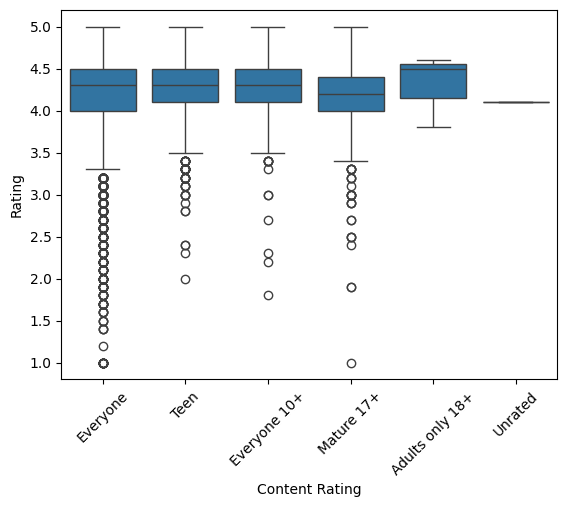

In [37]:
sns.boxplot(x='Content Rating', y='Rating', data=df)
plt.xticks(rotation=45)
plt.show()

In [38]:
df[df['Installs'] > 1000000]['Genres'].value_counts().head()

Genres
Tools            187
Action           182
Photography      161
Communication    146
Productivity     124
Name: count, dtype: int64

In [39]:
df = df.sort_values(by=['App','Last Updated'])
df['Update Gap'] = df.groupby('App')['Last Updated'].diff().dt.days
df['Update Gap'].mean()

np.float64(6.137931034482759)

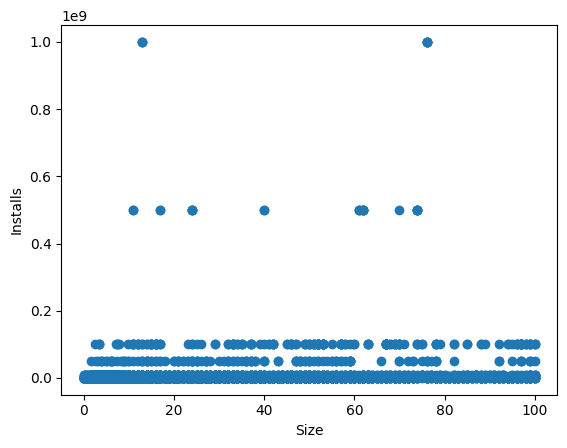

In [40]:
plt.scatter(df['Size'], df['Installs'])
plt.xlabel("Size")
plt.ylabel("Installs")
plt.show()

In [41]:
df.sort_values(by='Reviews', ascending=False)[['App','Reviews','Rating']].head()

,App,Reviews,Rating
2544,Facebook,78158306,4.1
3943,Facebook,78128208,4.1
336,WhatsApp Messenger,69119316,4.4
3904,WhatsApp Messenger,69109672,4.4
2604,Instagram,66577446,4.5


In [42]:
pd.crosstab(df['Content Rating'], df['Type'])

Type,Free,Paid
Content Rating,,
Adults only 18+,3,0
Everyone,6575,520
Everyone 10+,328,32
Mature 17+,395,16
Teen,977,45
Unrated,1,0


In [43]:
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head()

Category
GAME             31543862717
COMMUNICATION    24152241530
SOCIAL           12513841475
PRODUCTIVITY     12463070180
TOOLS            11450724500
Name: Installs, dtype: int64

In [44]:
bins = [0, 1e4, 1e5, 1e6, 1e7, 1e8]
labels = ['0-10K','10K-100K','100K-1M','1M-10M','10M+']

df['Install Group'] = pd.cut(df['Installs'], bins=bins, labels=labels)

df.groupby('Install Group')['Rating'].mean()

/tmp/ipykernel_55/1145495212.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Install Group')['Rating'].mean()


Install Group
0-10K       4.112427
10K-100K    4.094593
100K-1M     4.207043
1M-10M      4.285675
10M+        4.382995
Name: Rating, dtype: float64

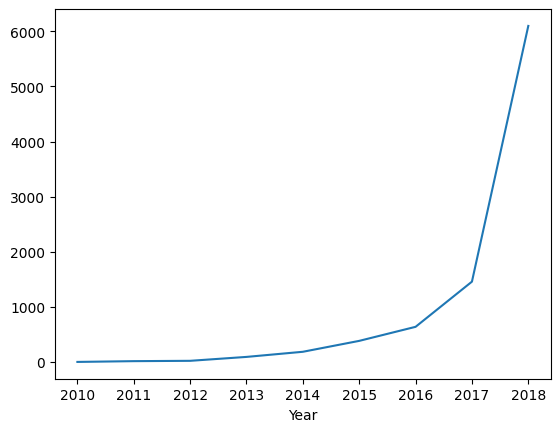

In [45]:
df['Year'] = df['Last Updated'].dt.year
df['Year'].value_counts().sort_index().plot()
plt.show()

In [47]:
cat_rating = df.groupby('Category')['Rating'].mean()
cat_installs = df.groupby('Category')['Installs'].sum()

(cat_installs / cat_rating).sort_values(ascending=False).head()

Category
GAME             7.367849e+09
COMMUNICATION    5.817762e+09
PRODUCTIVITY     2.966129e+09
SOCIAL           2.941030e+09
TOOLS            2.829148e+09
dtype: float64